[1680.455, 1694.82, 1663.965, 1670.409, 1666.578, 1660.952, 1654.154, 1673.748, 1655.458, 1658.508, 1670.216, 1664.939, 1656.439, 1691.149, 1661.583, 1674.02, 1669.645, 1684.807, 1652.679, 1661.217, 1669.778, 1667.721, 1674.719, 1664.541, 1660.792, 1679.232, 1666.962, 1662.159, 1680.802, 1673.808, 1661.361, 1674.736, 1677.6, 1655.848, 1696.522, 1655.95, 1666.46, 1693.724, 1671.182, 1653.674]


(array([7., 5., 5., 7., 5., 3., 3., 1., 1., 3.]),
 array([1652.679 , 1657.0633, 1661.4476, 1665.8319, 1670.2162, 1674.6005,
        1678.9848, 1683.3691, 1687.7534, 1692.1377, 1696.522 ]),
 <BarContainer object of 10 artists>)

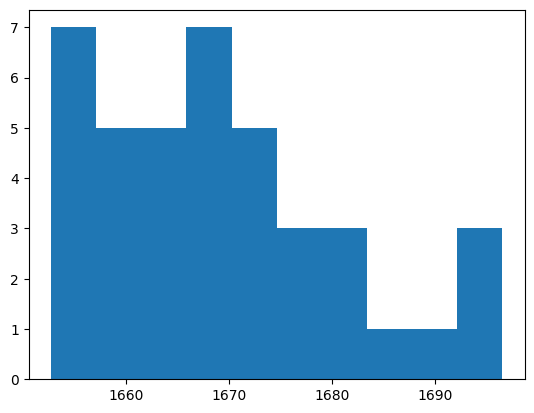

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math


prefix = "../results/"
instance = "pg_duckdb_parquet"
postfix = "_02_index.dat"
f = prefix + instance + postfix

t = []
with open(f, 'r') as file:
    for line in file:
        clear = line.strip()
        if clear:
            clear_dot = clear.replace(',', '.')
            t.append(float(clear_dot))
print(t)
plt.hist(t)

In [2]:
test_normal = stats.normaltest(t)
test_shapiro = stats.shapiro(t)
# print(test_normal, test_shapiro, sep = '\n')
print("Тест на нормальность данных: ", end='')
if test_normal[1] > 0.05 or test_shapiro[1] > 0.05:
    print("ПРОЙДЕН")
else:
    print("НЕ ПРОЙДЕН")

Тест на нормальность данных: ПРОЙДЕН


In [3]:
mean = np.mean(t)
std = np.std(t, ddof=1)
quality = (std / mean) * 100
print(f"Среднее: {mean}\nСтандартное отклонение: {std}\nОтношение std/mean (%): {quality}")

Среднее: 1669.3328000000001
Стандартное отклонение: 11.674205682527097
Отношение std/mean (%): 0.6993336309289013


In [4]:
interval = stats.t.ppf(0.975, df=len(t)-1)*stats.sem(t)
print(f"Доверительный интервал: {interval}")

Доверительный интервал: 3.733592108327355


### Округление
- Погрешность: 4 (мс)
- Среднее: 1669 (мс)
### Итог
- Результирующее значение: 1669 ± 4 (мс)